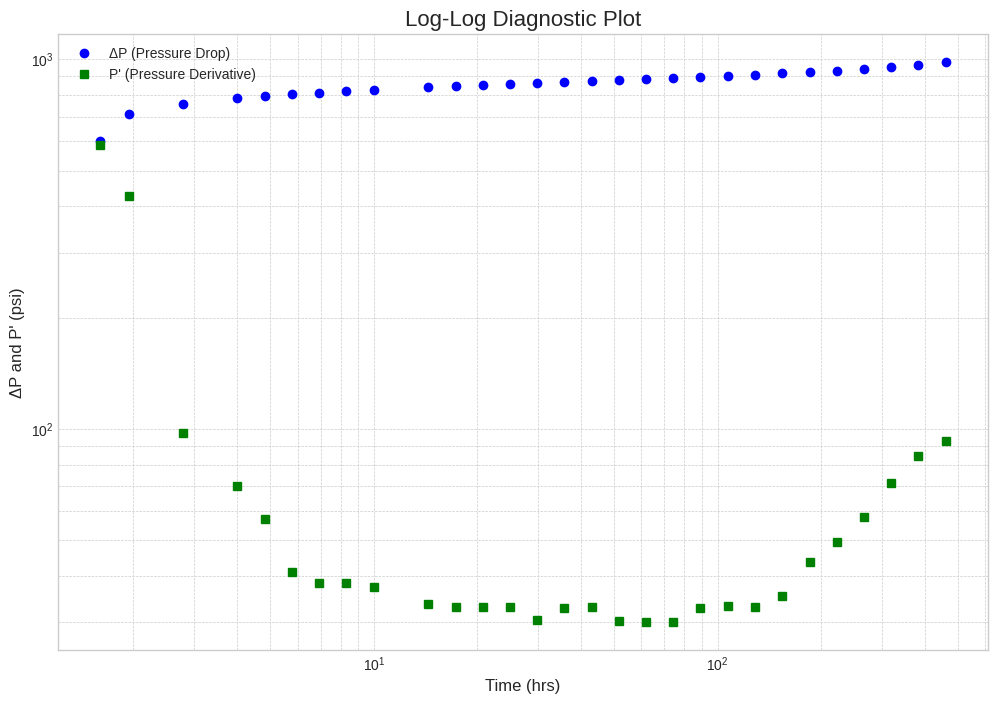

--- Well Test Analysis Results ---

Automatically selected IARF region: 24.90 – 89.10 hr
Derivative variation (CV): 0.0160
--- Transient Zone (IARF) ---
Average derivative value (P'): 31.53 psi
Calculated Permeability (k): 7.37 mD

Semi-log plot slope (m): 72.07 psi/cycle
Calculated Skin (S): 5.96



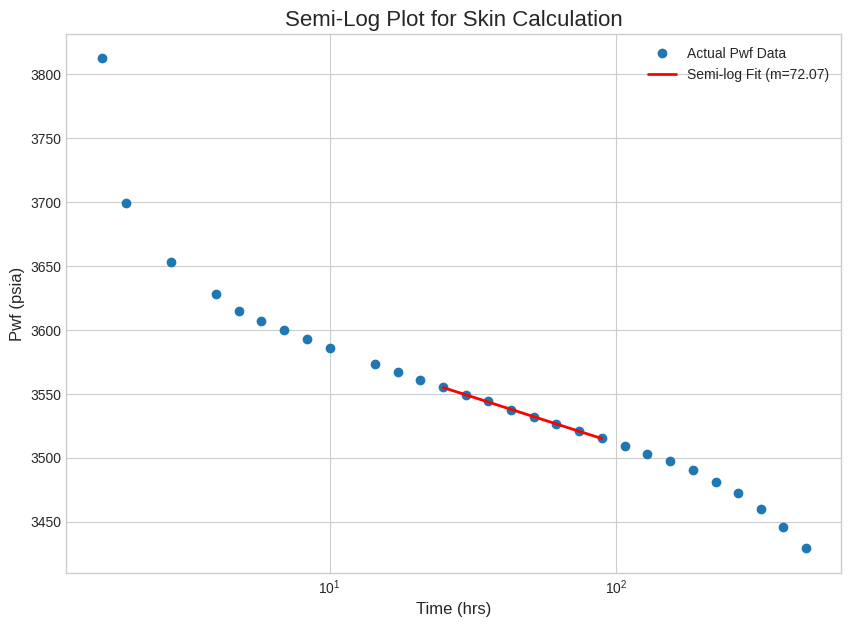

--- Semi-Steady State Zone ---
Unit slope constant C (from P'/t): 0.2160
Calculated Drainage Area (A): 6723051.80 acres

Cartesian plot intercept: 3530.75 psi
Calculated Dietz Shape Factor (C_A): 12.19



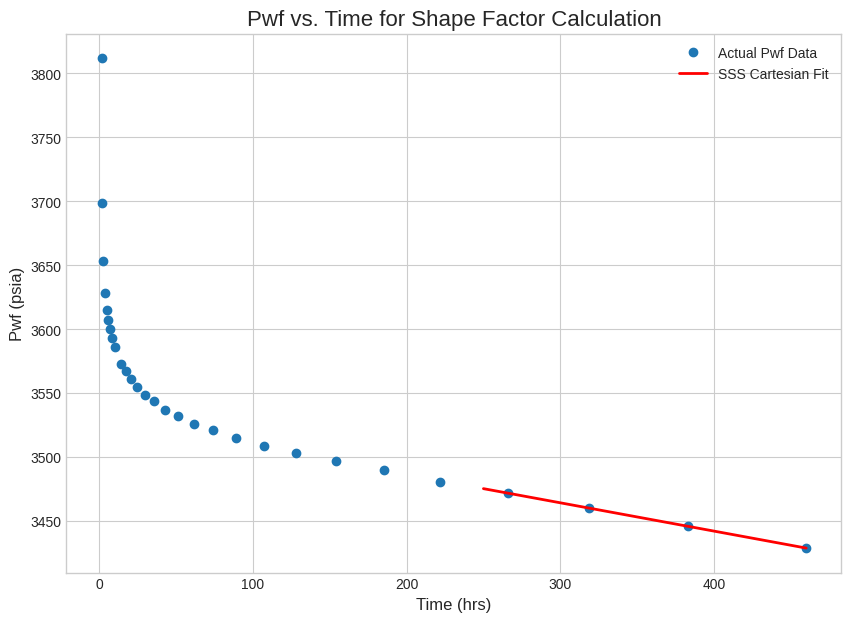

In [114]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

# --- 1. INPUT DATA ---

# Reservoir, Fluid, and Well Properties
params = {
    "Q": 250,        # Production rate, stb/d
    "h": 69,         # Formation thickness, ft
    "phi": 0.039,    # Porosity, fraction
    "ct": 17e-6,     # Total compressibility, psi^-1
    "Bo": 1.136,     # Oil formation volume factor, rb/stb
    "mu": 0.8,       # Oil viscosity, cp
    "rw": 0.198,     # Wellbore radius, ft
    "Pi": 4412,      # Initial reservoir pressure, psia
    "A_est": 151     # Estimated drainage area, acres
}

# Drawdown test data: Time (hrs) and Flowing Bottomhole Pressure (psia)
data = {
    't': [0, 1.6, 1.94, 2.79, 4.01, 4.82, 5.78, 6.94, 8.32, 9.99, 14.4, 17.3,
          20.7, 24.9, 29.8, 35.8, 43, 51.5, 61.8, 74.2, 89.1, 107, 128,
          154, 185, 222, 266, 319, 383, 460],
    'Pwf': [4412, 3812, 3699, 3653, 3628, 3615, 3607, 3600, 3593, 3586, 3573,
            3567, 3561, 3555, 3549, 3544, 3537, 3532, 3526, 3521, 3515,
            3509, 3503, 3497, 3490, 3481, 3472, 3460, 3446, 3429]
}
df = pd.DataFrame(data)


# --- 2. DATA PREPARATION ---

# Calculate pressure drop (delta P)
df['delta_P'] = params['Pi'] - df['Pwf']

# We can't use t=0 for log plots, so we'll work with a filtered dataframe
df_analysis = df[df['t'] > 0].copy()

# Calculate the pressure derivative d(delta_P) / d(ln(t))
# This is P' in your plots. We use numpy.gradient for a robust calculation.
df_analysis['P_prime'] = np.gradient(df_analysis['delta_P'], np.log(df_analysis['t']))


# --- 3. DIAGNOSTIC PLOT ---

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(12, 8))
ax.loglog(df_analysis['t'], df_analysis['delta_P'], 'o', color='blue', label='ΔP (Pressure Drop)')
ax.loglog(df_analysis['t'], df_analysis['P_prime'], 's', color='green', label="P' (Pressure Derivative)")
ax.set_title('Log-Log Diagnostic Plot', fontsize=16)
ax.set_xlabel('Time (hrs)', fontsize=12)
ax.set_ylabel('ΔP and P\' (psi)', fontsize=12)
ax.legend()
ax.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()


# --- 4. ANALYSIS & CALCULATIONS ---

print("--- Well Test Analysis Results ---\n")

# --- 4a. TRANSIENT ZONE (IARF) ANALYSIS ---

# Automatically identify a relatively stable pressure-derivative
# region from the diagnostic plot.

# Calculate a smoothed derivative for identifying the IARF region.
# The original P_prime values are still used for the calculations.
df_analysis['P_prime_smooth'] = (
    df_analysis['P_prime']
    .rolling(window=5, center=True)
    .mean()
)

# Remove rows where the rolling average is not available
df_derivative = df_analysis.dropna(
    subset=['P_prime_smooth']
).copy()

# Search for the most stable derivative region.
# A rolling coefficient of variation is used as a measure
# of derivative flatness.

window = 8

df_derivative['P_prime_mean'] = (
    df_derivative['P_prime_smooth']
    .rolling(window=window)
    .mean()
)

df_derivative['P_prime_std'] = (
    df_derivative['P_prime_smooth']
    .rolling(window=window)
    .std()
)

df_derivative['CV'] = (
    df_derivative['P_prime_std']
    / df_derivative['P_prime_mean'].abs()
)

# Avoid very early wellbore-storage dominated data
# and very late boundary-affected data.
candidate = df_derivative[
    (df_derivative['t'] >= 10) &
    (df_derivative['t'] <= 200)
].dropna(subset=['CV'])

# Select the region with the lowest derivative variation
best_index = candidate['CV'].idxmin()

# Identify the corresponding time interval
end_position = df_derivative.index.get_loc(best_index)

start_position = max(
    0,
    end_position - window + 1
)

iarf_indices = df_derivative.index[
    start_position:end_position + 1
]

df_iarf = df_analysis.loc[iarf_indices].copy()

t_start_iarf = df_iarf['t'].min()
t_end_iarf = df_iarf['t'].max()

print(
    f"Automatically selected IARF region: "
    f"{t_start_iarf:.2f} – {t_end_iarf:.2f} hr"
)

print(
    f"Derivative variation (CV): "
    f"{candidate.loc[best_index, 'CV']:.4f}"
)

# i. PERMEABILITY (k) from the derivative plot
# The flat line on the derivative plot gives us P'_avg
P_prime_avg = df_iarf['P_prime'].mean()
k = (70.6 * params['Q'] * params['Bo'] * params['mu']) / (params['h'] * P_prime_avg)
print(f"--- Transient Zone (IARF) ---")
print(f"Average derivative value (P'): {P_prime_avg:.2f} psi")
print(f"Calculated Permeability (k): {k:.2f} mD\n")

# ii. SKIN (S) from the semi-log plot (Pwf vs log10(t))
# Fit a straight line to the Pwf vs log10(t) data in the IARF region
slope_semilog, intercept_semilog, _, _, _ = linregress(np.log10(df_iarf['t']), df_iarf['Pwf'])

# Calculate Pwf at t=1hr (where log10(t)=0) from the fitted line
P_1hr = intercept_semilog
delta_P_1hr = params['Pi'] - P_1hr

# The slope of the line is m = abs(slope_semilog)
m = abs(slope_semilog)

# Calculate skin factor
term1 = delta_P_1hr / m
term2 = np.log10(k / (params['phi'] * params['mu'] * params['ct'] * params['rw']**2))
S = 1.1513 * (term1 - term2 + 3.23)
print(f"Semi-log plot slope (m): {m:.2f} psi/cycle")
print(f"Calculated Skin (S): {S:.2f}\n")

# Plotting the semi-log plot for verification
fig, ax = plt.subplots(figsize=(10, 7))
ax.semilogx(df_analysis['t'], df_analysis['Pwf'], 'o', label='Actual Pwf Data')
t_fit = np.logspace(np.log10(t_start_iarf), np.log10(t_end_iarf), 100)
pwf_fit = slope_semilog * np.log10(t_fit) + intercept_semilog
ax.semilogx(t_fit, pwf_fit, '-', color='red', linewidth=2, label=f'Semi-log Fit (m={m:.2f})')
ax.set_title('Semi-Log Plot for Skin Calculation', fontsize=16)
ax.set_xlabel('Time (hrs)', fontsize=12)
ax.set_ylabel('Pwf (psia)', fontsize=12)
ax.legend()
plt.show()

# --- 4b. SEMI-STEADY STATE (SSS) ANALYSIS ---

# **USER INPUT**: Select the time for the start of Semi-Steady State
# This is where the derivative has a unit slope, roughly after t=250 hrs
t_start_sss = 250
df_sss = df_analysis[df_analysis['t'] >= t_start_sss]

# i. DRAINAGE AREA (A) from the unit-slope line on the derivative plot
# Equation: log(P') = log(t) + log(C) => log(C) = log(P') - log(t)
# We calculate C = P'/t for each point and average it.
C = (df_sss['P_prime'] / df_sss['t']).mean()

# Now solve for Area (A)
A_acres = (0.2339 * params['Q'] * params['Bo']) / (C * params['h'] * params['phi'] * params['ct'])
A_sqft = A_acres * 43560  # Convert to sq. ft. for next calculation

print(f"--- Semi-Steady State Zone ---")
print(f"Unit slope constant C (from P'/t): {C:.4f}")
print(f"Calculated Drainage Area (A): {A_acres:.2f} acres\n")

# ii. DIETZ SHAPE FACTOR (C_A) from Pwf vs t plot
# Fit a straight line to the Pwf vs t data in the SSS region
slope_cart, intercept_cart, _, _, _ = linregress(df_sss['t'], df_sss['Pwf'])

# Calculate Dietz Shape Factor (C_A) from the intercept of the Pwf vs t plot
gamma = np.exp(0.5772) # Euler's constant, approx 1.781
term1 = (params['Pi'] - intercept_cart) * (k * params['h']) / (141.2 * params['Q'] * params['Bo'] * params['mu'])
term2 = (4 * A_sqft) / (gamma * params['rw']**2)
C_A = term2 / np.exp(2 * term1)
print(f"Cartesian plot intercept: {intercept_cart:.2f} psi")
print(f"Calculated Dietz Shape Factor (C_A): {C_A:.2f}\n")

# Plotting the cartesian plot for verification
fig, ax = plt.subplots(figsize=(10, 7))
ax.plot(df_analysis['t'], df_analysis['Pwf'], 'o', label='Actual Pwf Data')
t_fit_sss = np.array([t_start_sss, df_analysis['t'].max()])
pwf_fit_sss = slope_cart * t_fit_sss + intercept_cart
ax.plot(t_fit_sss, pwf_fit_sss, '-', color='red', linewidth=2, label='SSS Cartesian Fit')
ax.set_title('Pwf vs. Time for Shape Factor Calculation', fontsize=16)
ax.set_xlabel('Time (hrs)', fontsize=12)
ax.set_ylabel('Pwf (psia)', fontsize=12)
ax.legend()
plt.show()

In [116]:
df.to_csv("well_test_data.csv", index=False)
